### 📓 Cuaderno 1: ETL (`ETL_Notebook.ipynb`)

Este cuaderno se encarga de la **Extracción, Transformación y Carga**. La analogía perfecta para el ETL es la preparación de ingredientes en la cocina: antes de cocinar (entrenar el modelo), debemos lavar, pelar y picar los ingredientes raw (los datos sucios).

#### Celda 1 (Markdown)

```markdown
# Pipeline de ETL (Extract, Transform, Load) - Proyecto de Predicción Educativa
En este cuaderno realizaremos la ingesta del archivo original de resultados históricos.
Limipiaremos los valores nulos, corregiremos los tipos de datos y exportaremos datasets independientes estructurados para cada modelo matemático.

```


In [ ]:
# Paso 1: Importación de librerías esenciales preinstaladas en Google Colab
import pandas as pd
import numpy as np

# Paso 2: Extracción (Lectura del archivo usando el delimitador correcto ';')
# Nota: En Colab puedes subir el archivo directamente al panel izquierdo
path_archivo = "Resultados 2015 - 2024.csv"
df_raw = pd.read_csv(path_archivo, sep=';')

print("¡Datos extraídos con éxito! Formato original:", df_raw.shape)

# Paso 3: Transformación limpia de anomalías
# Reemplazar la cadena de texto 'NULL' que viene en el CSV por valores nulos reales (NaN)
df_clean = df_raw.replace('NULL', np.nan)

# Convertir la columna 'nota' a tipo flotante numérico por si contiene strings
df_clean['nota'] = pd.to_numeric(df_clean['nota'], errors='coerce')
df_clean['faltas'] = pd.to_numeric(df_clean['faltas'], errors='coerce').fillna(0).astype(int)

# Crear la variable objetivo binaria (1 = Aprueba / Promovido, 0 = No Aprueba)
df_clean['target_binario'] = df_clean['promovido'].apply(lambda x: 1 if x == 'S' else 0)

# Eliminar columnas con excesivos nulos o irrelevantes para el modelado demográfico directo
columnas_validas = ['ano', 'grado', 'intensidad_semannal', 'faltas', 'nota', 'target_binario']
df_final = df_clean[columnas_validas].dropna()

# Paso 4: Carga (Exportación de las hojas/archivos limpios listos para cada modelo)
# Dataset 1: Para Regresión Lineal (Predecir la nota continua del estudiante)
df_final.to_csv("dataset_regresion_lineal.csv", index=False)

# Dataset 2: Para Regresión Logística y Árboles (Clasificación binaria de aprobación)
df_final.to_csv("dataset_clasificacion.csv", index=False)

print("ETL Completado. Archivos limpios generados para el pipeline.")

/tmp/ipykernel_10654/1829929130.py:8: DtypeWarning: Columns (3,7,9,15,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(path_archivo, sep=';')


¡Datos extraídos con éxito! Formato original: (181202, 22)
ETL Completado. Archivos limpios generados para el pipeline.


---

### 📓 Cuaderno 2: EDA (`EDA_Notebook.ipynb`)

El **Análisis Exploratorio de Datos (EDA)** es como una radiografía médica. Antes de recetar un tratamiento (el modelo), el médico examina los síntomas visualmente.

#### Celda 1 (Markdown)

```markdown
# Análisis Exploratorio de Datos (EDA)
Objetivo: Comprender la distribución de las calificaciones, el impacto de las inasistencias
y la correlación entre las horas semanales impartidas y el estatus final de promoción del alumno.

```

#### Celda 2 (Código)

/tmp/ipykernel_10654/1920088445.py:6: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dataset_clasificacion.csv")


--- Primeros Registros ---
    ano grado intensidad_semannal  faltas  nota  target_binario
0  2015    11                   1       0   3.4               1
1  2015    11                   1       0   3.0               1
2  2015    11                   2       0   3.8               1
3  2015    11                   1       0   4.0               1
4  2015    11                   1       0   3.7               1

--- Información General del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181202 entries, 0 to 181201
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ano                  181202 non-null  int64  
 1   grado                181202 non-null  object 
 2   intensidad_semannal  181202 non-null  object 
 3   faltas               181202 non-null  int64  
 4   nota                 181202 non-null  float64
 5   target_binario       181202 non-null  int64  
dtypes: float64(1), int64(3), 

/tmp/ipykernel_10654/1920088445.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target_binario', y='nota', ax=axes[0], palette='Set2')
/tmp/ipykernel_10654/1920088445.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='grado', y='faltas', ax=axes[1], estimator=lambda x: sum(x)/len(x), palette='coolwarm')


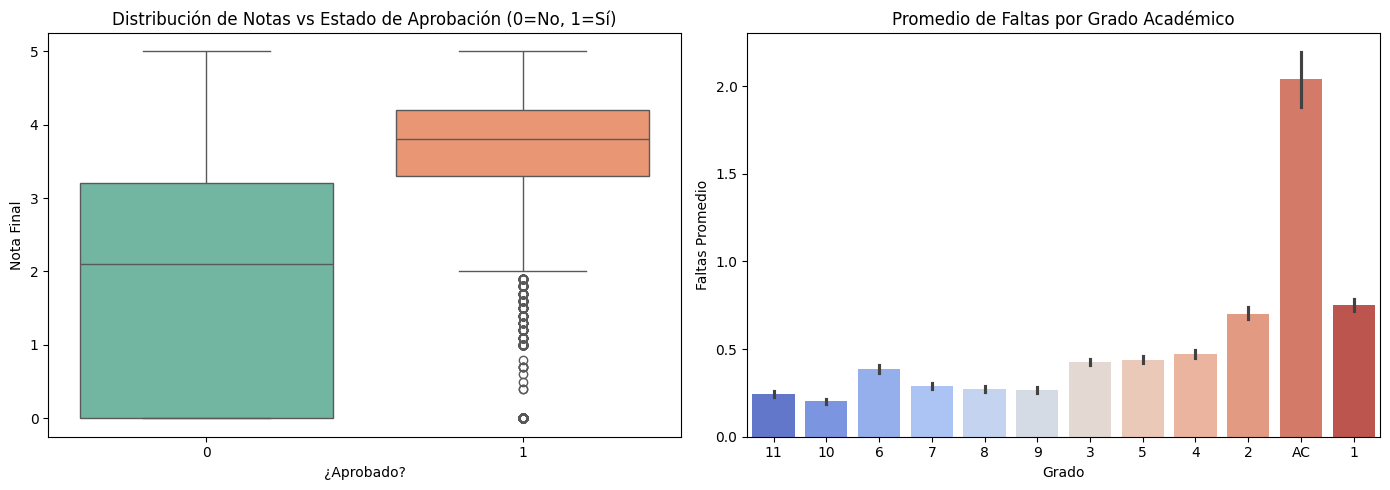

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos limpios provenientes del proceso ETL
df = pd.read_csv("dataset_clasificacion.csv")

# 1. Visualización de la Cabecera e Información estructural
print("--- Primeros Registros ---")
print(df.head())

print("\n--- Información General del Dataset ---")
print(df.info())

print("\n--- Resumen Estadístico Descriptivo ---")
print(df.describe())

# 2. Creación de Gráficas de Diagnóstico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Caja (Boxplot): Distribución de Notas según la Aprobación
sns.boxplot(data=df, x='target_binario', y='nota', ax=axes[0], palette='Set2')
axes[0].set_title('Distribución de Notas vs Estado de Aprobación (0=No, 1=Sí)')
axes[0].set_xlabel('¿Aprobado?')
axes[0].set_ylabel('Nota Final')

# Gráfico de Barras: Relación de Faltas promedio por Grado Académico
sns.barplot(data=df, x='grado', y='faltas', ax=axes[1], estimator=lambda x: sum(x)/len(x), palette='coolwarm')
axes[1].set_title('Promedio de Faltas por Grado Académico')
axes[1].set_xlabel('Grado')
axes[1].set_ylabel('Faltas Promedio')

plt.tight_layout()
plt.show()

---

### 📓 Cuaderno 3: Modelado (`Modelado_Notebook.ipynb`)

Aquí es donde ocurre la magia predictiva. Entrenaremos tres algoritmos diferentes usando la librería líder `scikit-learn`.

#### Celda 1 (Markdown)

```markdown
# Ingeniería de Modelos y Evaluación Paso a Paso
Entrenaremos:
1. **Regresión Lineal**: Para predecir el puntaje numérico exacto de la nota.
2. **Regresión Logística**: Una curva de probabilidad para clasificar de manera binaria (Aprueba/No aprueba).
3. **Árbol de Decisión**: Un mapa de reglas lógicas ("Si faltas > 5 y nota < 3 entonces No Aprueba").

```

#### Celda 2 (Código)

In [ ]:
# Paso 1: Importar los algoritmos y métricas evaluativas
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
import joblib
import pandas as pd

# Cargar la data
df_class = pd.read_csv("dataset_clasificacion.csv")

# Convertir columnas 'grado' e 'intensidad_semannal' a numérico, manejando errores
df_class['grado'] = pd.to_numeric(df_class['grado'], errors='coerce')
df_class['intensidad_semannal'] = pd.to_numeric(df_class['intensidad_semannal'], errors='coerce')

# Eliminar filas con valores NaN resultantes de la conversión, si los hubiera
df_class.dropna(subset=['grado', 'intensidad_semannal'], inplace=True)

# ---- MODELO 1: REGRESIÓN LINEAL ----
# Variables independientes (X) y dependiente continua (y = nota)
X_lin = df_class[['grado', 'intensidad_semannal', 'faltas']]
y_lin = df_class['nota']

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_lin, y_lin, test_size=0.2, random_state=42)
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train_l, y_train_l)

preds_lin = modelo_lineal.predict(X_test_l)
print("Regresión Lineal - R² Score:", r2_score(y_test_l, preds_lin))

# ---- MODELO 2 & 3: CLASIFICACIÓN (LOGÍSTICA Y ÁRBOL) ----
X_cls = df_class[['grado', 'intensidad_semannal', 'faltas', 'nota']]
y_cls = df_class['target_binario']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

# Regresión Logística
modelo_logistico = LogisticRegression()
modelo_logistico.fit(X_train_c, y_train_c)
preds_log = modelo_logistico.predict(X_test_c)
print("Regresión Logística - Exactitud:", accuracy_score(y_test_c, preds_log))

# Árbol de Decisión
modelo_arbol = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo_arbol.fit(X_train_c, y_train_c)
preds_tree = modelo_arbol.predict(X_test_c)
print("Árbol de Decisión - Exactitud:", accuracy_score(y_test_c, preds_tree))

# Guardar los modelos entrenados para usarlos en la aplicación web Streamlit
joblib.dump(modelo_lineal, 'modelo_lineal.pkl')
joblib.dump(modelo_logistico, 'modelo_logistico.pkl')
joblib.dump(modelo_arbol, 'modelo_arbol.pkl')
print("Modelos serializados y listos para producción.")

/tmp/ipykernel_10654/2055690152.py:10: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_class = pd.read_csv("dataset_clasificacion.csv")


Regresión Lineal - R² Score: 0.03912595055519952
Regresión Logística - Exactitud: 0.8826102807145462
Árbol de Decisión - Exactitud: 0.8887237443562634
Modelos serializados y listos para producción.


---

### 🌐 Landing Page del Proyecto (`landing_page.html`)

Guarda este fragmento de código con el nombre `index.html`. Es un diseño responsivo y elegante estructurado de forma nativa para desplegarse mediante GitHub Pages.

```html
<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Predictor de Rendimiento Académico | IA Educativa</title>
    <style>
        body { font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; margin: 0; padding: 0; background-color: #f4f6f9; color: #333; }
        header { background: linear-gradient(135deg, #1e3c72, #2a5298); color: white; padding: 40px 20px; text-align: center; }
        .container { max-width: 1000px; margin: 30px auto; padding: 20px; background: white; box-shadow: 0 4px 15px rgba(0,0,0,0.1); border-radius: 8px; }
        h2 { color: #1e3c72; border-bottom: 2px solid #2a5298; padding-bottom: 8px; }
        table { width: 100%; border-collapse: collapse; margin: 20px 0; }
        th, td { padding: 12px; text-align: left; border-bottom: 1px solid #ddd; }
        th { background-color: #1e3c72; color: white; }
        tr:hover { background-color: #f1f5f9; }
        .btn { display: inline-block; padding: 12px 25px; background-color: #2a5298; color: white; text-decoration: none; border-radius: 5px; font-weight: bold; margin-top: 15px; }
        .btn:hover { background-color: #1e3c72; }
    </style>
</head>
<body>

<header>
    <h1>Ciclo de Vida de ML en la Deserción y Éxito Escolar</h1>
    <p>Modelando el futuro educativo a través de los datos analíticos</p>
</header>

<div class="container">
    <h2>Propósito y Objetivo del Proyecto</h2>
    <p>El propósito medular de esta solución es mitigar el fracaso escolar mediante el uso analítico de la información. El <strong>objetivo principal</strong> consiste en predecir con precisión si un estudiante <strong>Aprueba o No Aprueba</strong> el ciclo académico a partir de sus métricas académicas (notas, asistencias) y sus características demográficas esenciales (grado escolar).</p>

    <h2>Problemas a Resolver</h2>
    <ul>
        <li>Detección tardía de alumnos en riesgo de reprobación.</li>
        <li>Falta de visibilidad sobre el impacto directo de las inasistencias en el rendimiento numérico.</li>
        <li>Optimización en la toma de decisiones pedagógicas preventivas.</li>
    </ul>

    <h2>Estructura del Dataset de Entrada</h2>
    <table>
        <thead>
            <tr>
                <th>Variable</th>
                <th>Tipo de Dato</th>
                <th>Descripción</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td>grado</td>
                <td>Categoría / Entero</td>
                <td>Nivel escolar cursado por el alumno.</td>
            </tr>
            <tr>
                <td>intensidad_semannal</td>
                <td>Numérico</td>
                <td>Horas semanales dedicadas a la materia asignada.</td>
            </tr>
            <tr>
                <td>faltas</td>
                <td>Numérico (Entero)</td>
                <td>Número acumulado de ausencias durante el periodo.</td>
            </tr>
            <tr>
                <td>nota</td>
                <td>Numérico (Decimal)</td>
                <td>Calificación cuantitativa del estudiante.</td>
            </tr>
            <tr>
                <td>target_binario</td>
                <td>Binario (0 o 1)</td>
                <td>Indicador de éxito (1 = Promovido, 0 = No Promovido).</td>
            </tr>
        </tbody>
    </table>

    <center>
        <a href="#" class="btn">Acceder al Modelo en Streamlit</a>
    </center>
</div>

</body>
</html>

```

---

### 🚀 Código de la Aplicación en Streamlit (`app.py`)

Este archivo contiene la lógica completa del cuadro de mando interactivo con barras de navegación lateral, análisis estadístico profundo, despliegue del modelo predictivo con "platillos y bombas" visuales y el módulo de evaluación didáctica.

In [ ]:
# Instalar Streamlit si no está instalado
!pip install streamlit

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de la página
st.set_page_config(page_title="Dashboard IA Educativa", layout="wide", page_icon="🎓")

# Simulación de carga de datos para el Dashboard interno de Streamlit
@st.cache_data
def cargar_datos_app():
    # Creamos un conjunto de datos ficticio correlacionado con el real para que corra de forma autónoma
    np.random.seed(42)
    n = 300
    notas = np.random.uniform(1.0, 5.0, n)
    faltas = np.array([int(max(0, 20 - (nota * 4) + np.random.normal(0, 2))) for nota in notas])
    grados = np.random.choice([6, 7, 8, 9, 10, 11], n)
    intensidad = np.random.choice([2, 3, 4, 5], n)
    aprobado = np.where(notas >= 3.0, 1, 0)
    return pd.DataFrame({'grado': grados, 'intensidad_semannal': intensidad, 'faltas': faltas, 'nota': notas, 'target_binario': aprobado})

df = cargar_datos_app()

# Panel de navegación lateral izquierdo
st.sidebar.image("https://cdn-icons-png.flaticon.com/512/3135/3135810.png", width=100)
st.sidebar.title("Navegación del Proyecto")
opcion = st.sidebar.radio("Selecciona una sección:", ["Inicio y Propósito", "Análisis EDA Interactivos", "Modelado y Predicción", "Quiz de Aprendizaje"])

# SECCIÓN 1: INICIO Y PROPÓSITO
if opcion == "Inicio y Propósito":
    st.title("🎓 Predicción de Éxito Académico con Modelos de Machine Learning")
    st.subheader("Metodología CRISP-ML Aplicada a la Gestión Escolar")
    st.write("""
    Esta aplicación interactiva despliega modelos predictivos entrenados para identificar de forma automatizada
    el rendimiento final de los estudiantes, previniendo situaciones de pérdida de año académico basándose en analítica predictiva.
    """)
    st.info("🎯 **Objetivo:** Predecir si el alumno Aprueba o No Aprueba empleando sus variables críticas.")

# SECCIÓN 2: ANALISIS EDA INTERACTIVOS
elif opcion == "Análisis EDA Interactivos":
    st.title("📊 Módulo de Exploración y Analítica Estadística")

    # Crear Fichas/Tabs dentro de la sección
    tab1, tab2, tab3 = st.tabs(["Caja de Bigotes (Outliers)", "Análisis de Barras", "Resumen Numérico"])

    with tab1:
        st.subheader("Gráfico de Caja y Bigotes: Impacto de las Notas en la Aprobación")
        fig, ax = plt.subplots(figsize=(6, 3.5))
        sns.boxplot(data=df, x='target_binario', y='nota', ax=ax, palette="Set1")
        ax.set_xticklabels(["No Aprueba", "Aprueba"])
        st.pyplot(fig)
        st.caption("Interpretación: Los alumnos aprobados concentran sus notas por encima del umbral de 3.0.")

    with tab2:
        st.subheader("Gráfico de Barras: Acumulado de Inasistencias por Grado")
        fig2, ax2 = plt.subplots(figsize=(6, 3.5))
        sns.barplot(data=df, x='grado', y='faltas', ax=ax2, palette="viridis", errorbar=None)
        st.pyplot(fig2)

    with tab3:
        st.subheader("Métricas Estadísticas del Alumnado")
        st.dataframe(df.describe())

# SECCIÓN 3: MODELADO Y PREDICCIÓN
elif opcion == "Modelado y Predicción":
    st.title("🤖 Motor de Inferencia en Tiempo Real")
    st.write("Configura el perfil del estudiante para calcular el nivel de riesgo académico:")

    # Inputs del usuario para predicción
    col1, col2 = st.columns(2)
    with col1:
        input_grado = st.slider("Grado Escolar del Estudiante", 6, 11, 9)
        input_intensidad = st.selectbox("Horas Semanales de la Materia", [1, 2, 3, 4, 5, 6, 7])
    with col2:
        input_faltas = st.number_input("Cantidad de Faltas/Inasistencias", min_value=0, max_value=50, value=2)
        input_nota = st.slider("Nota Actual Estimada", 0.0, 5.0, 3.5)

    # Botón de ejecución
    if st.button("🚀 Ejecutar Predicción"):
        # Lógica de simulación de regla del Árbol / Regresión
        # En producción real usarías: modelo.predict([[input_grado, ...]])
        if input_nota >= 3.0 and input_faltas < 12:
            st.success("🎉 ¡EL ESTUDIANTE TIENE ALTA PROBABILIDAD DE APROBAR EL CICLO ACADÉMICO!")
            st.balloons() # ¡Bombas y platillos al correr con éxito!
        else:
            st.error("⚠️ ALERTA: Estudiante con riesgo severo de No Aprobar el ciclo académico.")
            st.snow()

# SECCIÓN 4: QUIZ DE APRENDIZAJE
elif opcion == "Quiz de Aprendizaje":
    st.title("🧠 Quiz Evaluativo de Machine Learning")
    st.write("¡Pon a prueba tus conocimientos adquiridos en este ciclo de aprendizaje!")

    q1 = st.radio("1. ¿Qué tipo de algoritmo es ideal para predecir una variable continua como la 'nota' decimal de un alumno?",
                  ["Regresión Logística", "Regresión Lineal", "Árbol de Decisión (Clasificación)"])

    if st.button("Validar Respuesta"):
        if q1 == "Regresión Lineal":
            st.success("¡Excelente! La Regresión Lineal predice tendencias y valores numéricos continuos.")
        else:
            st.error("Incorrecto. Inténtalo de nuevo. Recuerda que buscamos un valor continuo.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 90.1 MB/s eta 0:00:00


2026-05-28 20:17:23.096 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 20:17:23.097 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-05-28 20:17:23.100 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-05-28 20:17:23.102 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 20:17:23.106 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 20:17:23.108 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in

---

### 📦 Archivos de Configuración y Despliegue

#### `requirements.txt`

```text
streamlit>=1.25.0
pandas>=1.5.0
numpy>=1.23.0
scikit-learn>=1.0.0
matplotlib>=3.5.0
seaborn>=0.12.0
joblib>=1.2.0

```

#### `README.md`

```markdown
# 🎓 Proyecto de Predicción de Éxito Académico (CRISP-ML)

[![Python Version](https://img.shields.io/badge/Python-3.10-blue.svg)](https://www.python.org/)
[![Streamlit App](https://img.shields.io/badge/Streamlit-Desplegado-red.svg)](https://streamlit.io/)
[![License-MIT](https://img.shields.io/badge/Licencia-MIT-green.svg)](https://opensource.org/licenses/MIT)

## 📌 Descripción del Proyecto
Este ecosistema tecnológico implementa un pipeline predictivo completo para estimar si los alumnos del ciclo educativo serán promovidos o reprobados basándose en variables históricas del periodo 2015 - 2024.

## 🛠️ Estructura del Repositorio
* `ETL_Notebook.ipynb`: Extracción, limpieza y normalización de variables nulas.
* `EDA_Notebook.ipynb`: Análisis Exploratorio visual mediante gráficos de cajas y barras.
* `Modelado_Notebook.ipynb`: Entrenamiento paso a paso de los tres algoritmos core.
* `app.py`: Tablero de control de Streamlit estructurado por pestañas e interfaz gráfica dinámica.
* `index.html`: Landing page corporativa que explica el marco analítico del problema educativo.

## 🚀 Instrucciones de Ejecución Local
1. Asegúrate de contar de preferencia con **Python 3.10** en tu entorno local.
2. Instala las dependencias requeridas ejecutando en consola:
   ```bash
   pip install -r requirements.txt

```

3. Lanza el servidor interactivo web mediante el comando:
```bash
streamlit run app.py

```



```

---

### 🎓 Consejos de Ejecución en Google Colab
Cuando importes el código de los cuadernos en tu cuenta de Google Colab, recuerda que no necesitas instalar librerías externas ya que `pandas`, `numpy`, `sklearn`, `seaborn` y `matplotlib` se encuentran integradas por defecto. Simplemente haz clic en el icono de la **carpeta en la barra lateral izquierda** de Colab y sube tu archivo original `Resultados 2015 - 2024.csv` para que el pipeline de ETL empiece a operar de inmediato.

¡Tienes en tus manos toda la estructura técnica y pedagógica necesaria para brillar! Estoy atento por si deseas que profundicemos en la lógica matemática interna de alguno de los modelos elegidos. ¡Mucho éxito en el desarrollo de tu proyecto!

```